<center><font size=8>RAG-BASED MEDICAL KNOWLEDGE ASSISTANT</font></center>

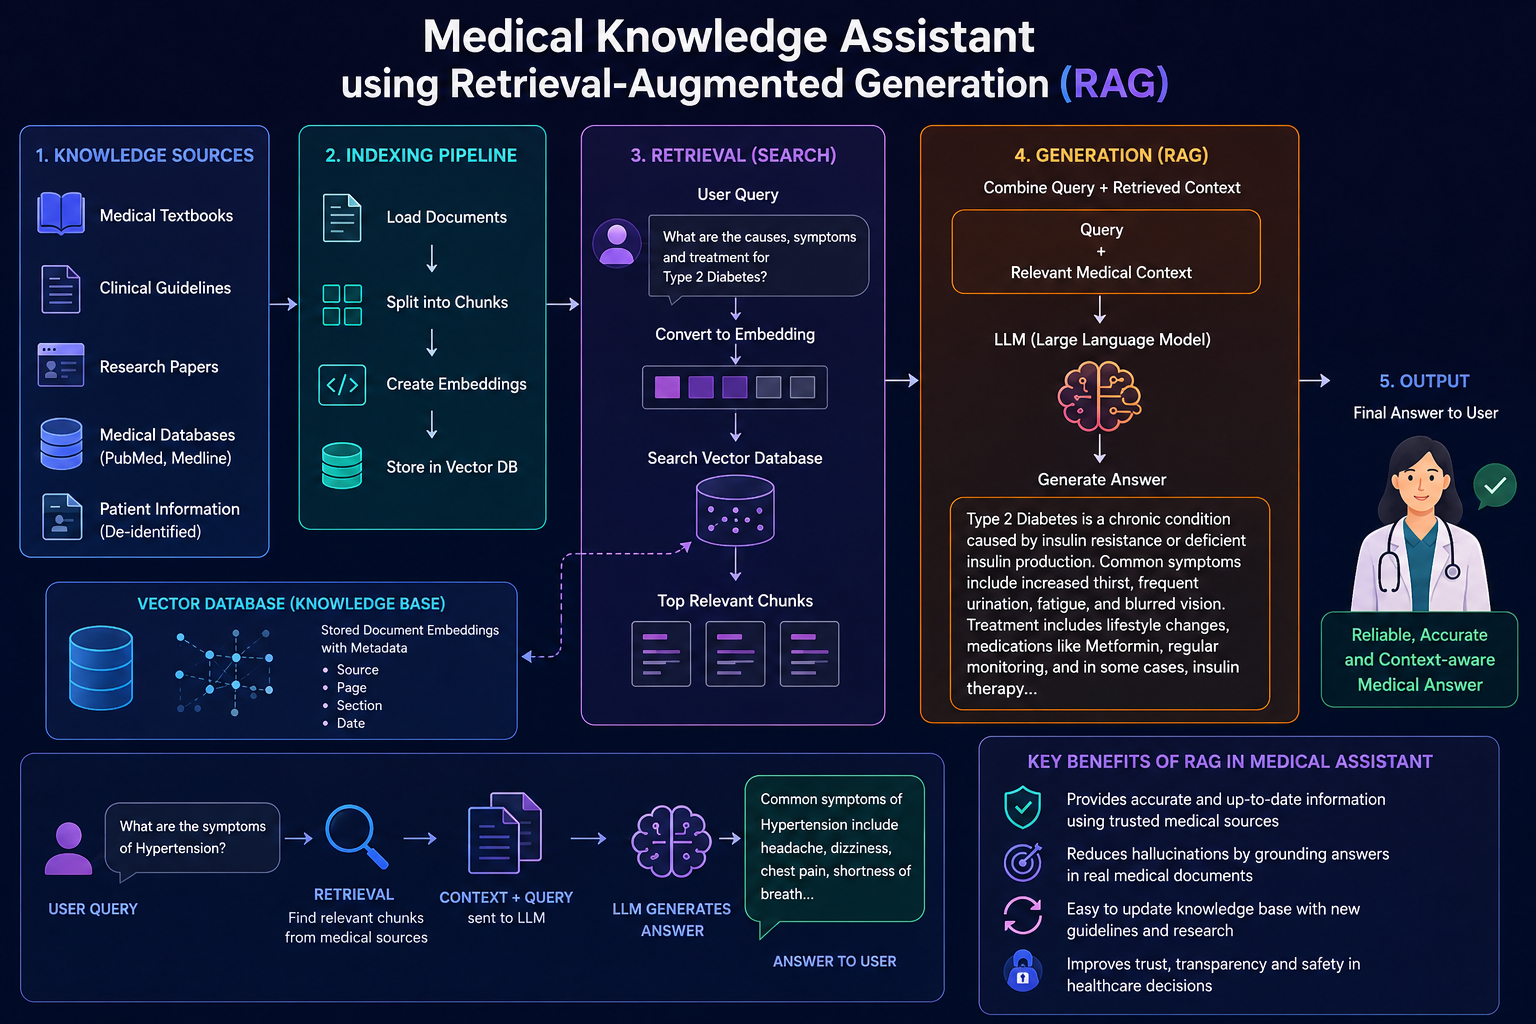

##📌Problem Statement

### 💼 Business Context

The healthcare industry is rapidly evolving, with professionals facing increasing challenges in managing vast volumes of medical data while delivering accurate and timely diagnoses. The need for quick access to comprehensive, reliable, and up-to-date medical knowledge is critical for improving patient outcomes.

Healthcare professionals often encounter information overload, struggling to sift through extensive research and data to create accurate diagnoses and treatment plans. This challenge is amplified by the need for efficiency, particularly in emergencies, where time-sensitive decisions are vital.

To address these challenges, healthcare centers can focus on integrating systems that streamline access to medical knowledge, provide tools to support quick decision-making, and enhance efficiency.

**Common Questions to Answer**

1. **Critical Care Protocols:** "What is the protocol for managing sepsis in a critical care unit?"

2. **General Surgery:** "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"

3. **Dermatology:** "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"

4. **Neurology:** "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"


## Project Objectives

The core objectives of this project are to:

✅ Develop an `AI assistant` designed to answer `medical inquiries` using authoritative `knowledge sources`.

✅ Build a `Retrieval-Augmented Generation (RAG) pipeline` to produce evidence-backed answers.

✅ Compare standard **LLM responses** against **context-informed RAG responses**.

✅ Assess answer quality using `**Groundedness**` and `**Relevance**` evaluation metrics.

✅ Illustrate how RAG enhances reliability, factual correctness, and clinical decision support in medical contexts.

### 📊 Data Description

The **Merck Manuals** are medical references published by the American pharmaceutical company Merck & Co., that cover a wide range of medical topics, including disorders, tests, diagnoses, and drugs. The manuals have been published since 1899, when Merck & Co. was still a subsidiary of the German company Merck.

- The manual is provided as a PDF with over 4,000 pages divided into 23 sections.

## Resources

This section describes additional resources or data used in the project.

##  📩Installing and Importing Necessary Libraries and Dependencies

In [ ]:
# Install required libraries
!pip install -q langchain_community==0.3.27 \
              langchain==0.3.27 \
              chromadb==1.0.15 \
              pymupdf==1.26.3 \
              tiktoken==0.9.0 \
              datasets==4.0.0 \
              evaluate==0.4.5 \
              langchain_openai==0.3.30 \
              sentence-transformers==2.7.0 \
              huggingface_hub>=0.25.0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
langgraph-sdk 0.4.2 requires langchain-core<2,>=1.4.0, but you have langchain-core 0.3.86 which is incompatible.
google-adk 2.4.0 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.44.0 which is incompatible.
google-adk 2.4.0 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have opentelemetry-sdk 1.44.0 which is incompatible.
langgraph 1.2.9 requires langchain-core<2,>=1.4.7, but you have langchain-core 0.3.86 which is incompatible.
langgraph-prebuilt 1.1.0 requires langchain-core>=1.3.1, but you have langchain-core 0.3.86 which is incompatible.


In [ ]:
# Install llama-cpp-python with GPU support for running LLaMA models
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.45 --force-reinstall --upgrade --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 6.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 268.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
langgraph-sdk 0.4.2 requires langchain-core<2,>=1.4.0, but you have langchain-core 0.3.86 which is incompatible.
google-adk 2.4.0 requires 

In [ ]:
# Removed: This cell was installing an older, conflicting version of huggingface_hub.
# The updated installation in cell 0VOckDVkWGei handles this dependency.

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

## **LLM with Prompt Engineering Response**

#### **Download LLaMA-2 13B Chat Model**

In [ ]:
from huggingface_hub import hf_hub_download

model_name_or_path = "TheBloke/Llama-2-13B-chat-GGUF"
model_basename = "llama-2-13b-chat.Q5_K_M.gguf"
model_path = hf_hub_download(                     # Download the model file from Hugging Face Hub and return its local path
    repo_id=model_name_or_path,
    filename=model_basename
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


llama-2-13b-chat.Q5_K_M.gguf:   0%|          | 0.00/9.23G [00:00<?, ?B/s]

#### **Initialize LLaMA Model with Configuration**

In [ ]:
from llama_cpp import Llama
lcpp_llm = Llama(
    model_path=model_path, # Path to the downloaded GGUF model
    n_threads=2, # Number of CPU threads to use
    n_batch=512, # Batch size for prompt processing
    n_gpu_layers=32, # Number of layers to offload to GPU
    n_ctx=4096 # Context window
)

llama_model_loader: loaded meta data with 19 key-value pairs and 363 tensors from /root/.cache/huggingface/hub/models--TheBloke--Llama-2-13B-chat-GGUF/snapshots/4458acc949de0a9914c3eab623904d4fe999050a/llama-2-13b-chat.Q5_K_M.gguf (version GGUF V2)
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = LLaMA v2
llama_model_loader: - kv   2:                       llama.context_length u32              = 4096
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 5120
llama_model_loader: - kv   4:                          llama.block_count u32              = 40
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 13824
llama_model_loader: - kv   6:                 llama.rope.dimension_

In [ ]:
# Provides an example and answer anchor to guide the model in giving concise, evidence-based responses without echoing the question.
system_prompt = """
You are a medical expert AI assistant. Respond with concise, evidence-based answers.
"""

user_prompt = """
Example:
Q: What are the common symptoms of appendicitis?
A: Common symptoms include abdominal pain (usually starting near the navel), nausea, vomiting, and fever.
References: Mayo Clinic, UpToDate

Now answer:
Q: What is the protocol for managing sepsis in a critical care unit?
A:
"""


#### **Response Function**

In [ ]:
# function to generate, process, and return the response from the LLM
def prompt_engineering_response(user_prompt):
    # Put the system message first, then the user question, then anchor with "Answer:"
    prompt = f"""{system_prompt}

Question: {user_prompt}

Answer:"""

    # Generate a response from the LLaMA model
    response = lcpp_llm(
        prompt,
        max_tokens=500,
        stop=["Question:", "\n"],
        echo=False,
        temperature=0.7,
    )

    # Extract and return the response text
    response_text = response["choices"][0]["text"].strip()
    return response_text

## Question Answering using LLM with Prompt Engineering

### Question 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
question_1 = "What is the protocol for managing sepsis in a critical care unit?"
response_1 = prompt_engineering_response(question_1)
print(response_1)


llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =      26.57 ms /    41 runs   (    0.65 ms per token,  1543.33 tokens per second)
llama_print_timings: prompt eval time =    1306.96 ms /    48 tokens (   27.23 ms per token,    36.73 tokens per second)
llama_print_timings:        eval time =   12798.76 ms /    40 runs   (  319.97 ms per token,     3.13 tokens per second)
llama_print_timings:       total time =   14279.67 ms /    88 tokens


The Surviving Sepsis Campaign (SSC) guidelines provide a comprehensive protocol for managing sepsis in a critical care unit. Here are the key recommendations:


### Question 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
question_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"
response_2 = prompt_engineering_response(question_2)
print(response_2)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =      14.94 ms /    25 runs   (    0.60 ms per token,  1673.14 tokens per second)
llama_print_timings: prompt eval time =     854.40 ms /    37 tokens (   23.09 ms per token,    43.31 tokens per second)
llama_print_timings:        eval time =    8348.02 ms /    24 runs   (  347.83 ms per token,     2.87 tokens per second)
llama_print_timings:       total time =    9304.59 ms /    61 tokens


Appendicitis is inflammation of the vermiform appendix that requires prompt medical attention. Common symptoms include:


### Question 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
question_3 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"
response_3 = prompt_engineering_response(question_3)
print(response_3)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =      23.02 ms /    34 runs   (    0.68 ms per token,  1476.72 tokens per second)
llama_print_timings: prompt eval time =     854.06 ms /    41 tokens (   20.83 ms per token,    48.01 tokens per second)
llama_print_timings:        eval time =   10898.54 ms /    33 runs   (  330.26 ms per token,     3.03 tokens per second)
llama_print_timings:       total time =   11896.15 ms /    74 tokens


Sudden patchy hair loss, also known as alopecia areata, can have various causes and effective treatments. Here are some possible causes and solutions:


### Question 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
question_4 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"
response_4 = prompt_engineering_response(question_4)
print(response_4)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =      38.37 ms /    61 runs   (    0.63 ms per token,  1589.95 tokens per second)
llama_print_timings: prompt eval time =     847.19 ms /    35 tokens (   24.21 ms per token,    41.31 tokens per second)
llama_print_timings:        eval time =   20207.59 ms /    60 runs   (  336.79 ms per token,     2.97 tokens per second)
llama_print_timings:       total time =   21301.62 ms /    95 tokens


Treatment options for a person who has sustained a physical injury to brain tissue and experienced impairment of brain function will depend on the severity and location of the injury, as well as the individual's overall health and medical history. However, some common treatment approaches may include:


#### **Create and Display Results DataFrame**

In [ ]:
# Create the DataFrame
import pandas as pd
prompt_result_df = pd.DataFrame({
    "questions": [question_1, question_2, question_3, question_4],
    "prompt_Engineering_responses": [response_1, response_2, response_3, response_4]
})

# Display the DataFrame
prompt_result_df.head()

,questions,prompt_Engineering_responses
0,What is the protocol for managing sepsis in a ...,The Surviving Sepsis Campaign (SSC) guidelines...
1,"What are the common symptoms for appendicitis,...",Appendicitis is inflammation of the vermiform ...
2,What are the effective treatments or solutions...,"Sudden patchy hair loss, also known as alopeci..."
3,What treatments are recommended for a person w...,Treatment options for a person who has sustain...


#### **Observations:**
*   Analyze the responses from the LLaMA model with prompt engineering. Do they directly answer the questions? Are they concise?
*   Note any instances where the model might hallucinate or provide overly general information without specific medical context. Compare these responses to expected expert-level answers.

## **RAG Response**

## **Data Preparation for RAG**

### **Loading the data**

In [ ]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from langchain_community.document_loaders import PyMuPDFLoader

# Load Merck Manual PDF
pdf_path = "/content/medical_diagnosis_manual.pdf" # Updated path to Google Drive
loader = PyMuPDFLoader(pdf_path)

# Load as LangChain Documents
document = loader.load()

print(f"Total pages loaded: {len(document)}")

Total pages loaded: 4114


for i in range(15,17):
    print(f"--- Page {i+1} ---")
    print(document[i].page_content)
    print("\n")

### Data Overview

Display the content of page number 16 and 17

In [ ]:
for i in range(15,17):
    print(f"--- Page {i+1} ---")
    print(document[i].page_content)
    print("\n")

--- Page 16 ---
degree. The book received critical acclaim and sold over 2 million copies. The Second Home Edition was
released in 2003. Merck's commitment to providing comprehensive, understandable medical information
to all people continued with The Merck Manual Home Health Handbook, published in 2009.
The Merck Manual of Health & Aging , published in 2004, continued Merck's commitment to education
and geriatric care, providing information on aging and the care of older people in words understandable
by the lay public.
In 2008, The Merck Manual of Patient Symptoms  was introduced to complement The Merck Manual
and was intended to help newcomers to clinical diagnosis approach patients who present with certain
common symptoms.
As part of its commitment to ensuring that all who need and want medical information can get it, Merck
provides the content of these Merck Manuals on the web for free (www.merckmanuals.com). Registration
is not required, and use is unlimited. The web publications

## **Data Chunking**

Split the document into Chunks and display the total chunks

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 200,
    length_function = len,
    is_separator_regex = False,
)
docs = text_splitter.split_documents(document)

print(f"Total chunks: {len(docs)}")

Total chunks: 17984


### Embedding

Generate Vector Embeddings for Text Chunks Using Hugging Face

### Set up Hugging Face Token

To authenticate with the Hugging Face Hub, which can be useful for accessing private models or avoiding rate limits, you can add your Hugging Face token to Colab Secrets.

1.  **Generate a token:** Go to your Hugging Face profile settings (https://huggingface.co/settings/tokens) and create a new access token (with 'read' role is usually sufficient for downloading).
2.  **Add to Colab Secrets:** Click on the '🔑' icon in the left panel of Colab, click 'Add new secret', set the name to `HF_TOKEN`, and paste your token as the value.
3.  **Enable 'Notebook access'** for `HF_TOKEN`.

Then run the cell below to load it as an environment variable.

In [ ]:
# Import necessary libraries
from google.colab import userdata
import os
from google.colab.userdata import SecretNotFoundError

# Retrieve the Hugging Face token from Colab secrets and set it as an environment variable
# This is optional, but recommended for accessing private models or avoiding rate limits.
try:
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    print("Hugging Face token loaded from Colab secrets.")
except SecretNotFoundError:
    print("Hugging Face token not found in Colab secrets. Proceeding without authentication, but authentication is recommended to avoid warnings or access private models.")
except Exception as e:
    print(f"An unexpected error occurred while loading HF_TOKEN: {e}")

Hugging Face token not found in Colab secrets. Proceeding without authentication, but authentication is recommended to avoid warnings or access private models.


In [ ]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings
import os

# For this notebook we will use OpenAIEmbeddings but other models can be used too
# For example, we can use open-source embedding models from Hugging Face via LangChain's HuggingFaceEmbeddings.
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
# embedding_model = OpenAIEmbeddings(model="text-embedding-3-small", openai_api_key=os.environ["OPENAI_API_KEY"])

/tmp/ipykernel_3481/4172579024.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
from langchain.vectorstores import Chroma
# Building the vector store and saving it to disk for future use
vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embedding_model,
    persist_directory="./chroma_db"
)

### Retriever

Retrieval and Response Generation using Vector Search

In [ ]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 5
    }
)

In [ ]:
medical_system_message = """
You are an AI assistant designed to support healthcare professionals by providing evidence-based, concise, and accurate responses using authoritative medical sources, such as the Merck Manuals.

Your goal is to help clinicians, researchers, and healthcare teams quickly access reliable medical knowledge to improve patient outcomes, support decision-making, and reduce information overload.

User input will include context extracted from trusted medical sources. This context will begin with the token:

###Context
The context may include excerpts from the Merck Manuals, clinical guidelines, or peer-reviewed medical literature, including titles, sections, authors, and other relevant metadata.

When crafting your response:
- Use only the provided context to answer the question.
- Provide concise, clinically relevant, and accurate answers.
- Include the source (title, section, and page/section reference) when applicable.
- If the context does not contain relevant information, respond: "Sorry, this is out of my knowledge base."
- Do NOT provide personal medical advice or treatment recommendations outside of the context.
- Maintain a professional, neutral, and safe tone appropriate for healthcare communication.

Example response format:

Answer:
[Answer based on context]

Source:
[Source title, section, page]
"""


In [ ]:
medical_user_message_template = """
###Context
Here are relevant excerpts from the Merck Manuals or other authoritative medical sources:
{context}

###Question
{question}
"""


### Response Function

In [ ]:
# The Llama-2 model (lcpp_llm) is assumed to be initialized in a previous cell (meAW-zUczsSr)

def generate_rag_response(user_input, retriever,
                          system_message, user_message_template,
                          k=5, max_tokens=500, temperature=0.3, top_p=0.95):

    # Retrieve relevant document chunks
    relevant_chunks = retriever.get_relevant_documents(user_input)
    if not relevant_chunks:
        return "Sorry, this is out of my knowledge base."

    # Combine document chunks with source info
    context_for_query = "\n".join([f"Source: {d.metadata.get('source','Unknown')}, Page: {d.metadata.get('page','Unknown')}\n{d.page_content}" for d in relevant_chunks])

    # Fill user message template
    user_message = user_message_template.format(context=context_for_query, question=user_input)

    # Combine system message and user message for the Llama model
    # The lcpp_llm expects a single prompt string
    full_prompt = f"{system_message}\n\n{user_message}"

    # Generate the response using lcpp_llm
    try:
        response = lcpp_llm(
            full_prompt,
            max_tokens=max_tokens,
            stop=["###Question", "\n"], # Adjust stop words as needed based on prompt structure
            echo=False,
            temperature=temperature,
            top_p=top_p
        )
        return response["choices"][0]["text"].strip()

    except Exception as e:
        return f"Sorry, I encountered the following error:\n{e}"

## Question Answering using RAG

### Question 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
question_1 = "What is the protocol for managing sepsis in a critical care unit?"

# Call the RAG response function
response_with_rag_1 = generate_rag_response(
    user_input=question_1,
    retriever=retriever,
    system_message=medical_system_message,
    user_message_template=medical_user_message_template,
    k=5,
    max_tokens=500,
    temperature=0.3,
    top_p=0.95
)

# Print the response
print(response_with_rag_1)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =       0.68 ms /     1 runs   (    0.68 ms per token,  1481.48 tokens per second)
llama_print_timings: prompt eval time =   17175.01 ms /  1790 tokens (    9.59 ms per token,   104.22 tokens per second)
llama_print_timings:        eval time =       0.00 ms /     1 runs   (    0.00 ms per token,      inf tokens per second)
llama_print_timings:       total time =   17199.11 ms /  1791 tokens


### Question 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
question_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"
response_with_rag_2 = generate_rag_response(
    user_input=question_2,
    retriever=retriever,
    system_message=medical_system_message,
    user_message_template=medical_user_message_template,
    k=5,
    max_tokens=500,
    temperature=0.3,
    top_p=0.95
)
print(response_with_rag_2)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =       0.57 ms /     1 runs   (    0.57 ms per token,  1748.25 tokens per second)
llama_print_timings: prompt eval time =    9743.70 ms /  1327 tokens (    7.34 ms per token,   136.19 tokens per second)
llama_print_timings:        eval time =       0.00 ms /     1 runs   (    0.00 ms per token,      inf tokens per second)
llama_print_timings:       total time =    9758.56 ms /  1328 tokens


### Question 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
question_3 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"
response_with_rag_3 = generate_rag_response(
    user_input=question_3,
    retriever=retriever,
    system_message=medical_system_message,
    user_message_template=medical_user_message_template,
    k=5,
    max_tokens=500,
    temperature=0.3,
    top_p=0.95
)
print(response_with_rag_3)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =       0.61 ms /     1 runs   (    0.61 ms per token,  1642.04 tokens per second)
llama_print_timings: prompt eval time =   12752.71 ms /  1353 tokens (    9.43 ms per token,   106.10 tokens per second)
llama_print_timings:        eval time =       0.00 ms /     1 runs   (    0.00 ms per token,      inf tokens per second)
llama_print_timings:       total time =   12763.87 ms /  1354 tokens


### Question 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
question_4 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"
response_with_rag_4 = generate_rag_response(
    user_input=question_4,
    retriever=retriever,
    system_message=medical_system_message,
    user_message_template=medical_user_message_template,
    k=5,
    max_tokens=500,
    temperature=0.3,
    top_p=0.95
)
print(response_with_rag_4)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =       0.64 ms /     1 runs   (    0.64 ms per token,  1562.50 tokens per second)
llama_print_timings: prompt eval time =    8544.10 ms /  1254 tokens (    6.81 ms per token,   146.77 tokens per second)
llama_print_timings:        eval time =       0.00 ms /     1 runs   (    0.00 ms per token,      inf tokens per second)
llama_print_timings:       total time =    8555.73 ms /  1255 tokens


In [ ]:
# Create the DataFrame

RAG_result_df = pd.DataFrame({
    "questions": [question_1, question_2, question_3, question_4],
    "RAG_responses": [response_with_rag_1, response_with_rag_2, response_with_rag_3, response_with_rag_4]
})

# Display the DataFrame
RAG_result_df.head()

,questions,RAG_responses
0,What is the protocol for managing sepsis in a ...,
1,"What are the common symptoms for appendicitis,...",
2,What are the effective treatments or solutions...,
3,What treatments are recommended for a person w...,


## Output Evaluation

In [ ]:
medical_groundedness_rater_system_message = """
You are tasked with rating AI-generated answers to medical questions posed by healthcare professionals.
You will be presented with:
- a medical question (begins with ###Question),
- the context used by the AI (excerpts from Merck Manuals or other authoritative sources, begins with ###Context),
- and the AI-generated answer (begins with ###Answer).

Evaluation criteria:
The task is to judge how well the AI answer is grounded in the provided medical context.

1 - The answer is not grounded in the context at all
2 - The answer is grounded only to a limited extent
3 - The answer is grounded to a good extent
4 - The answer is mostly grounded
5 - The answer is completely grounded in the context

Instructions:
1. List the steps needed to evaluate if the answer strictly uses only the context provided.
2. Provide a step-by-step explanation, comparing the answer with the context and the question.
3. Assign a groundedness score based on the above evaluation.
4. Return only the final score in dictionary format (not JSON), e.g.: {groundedness_score:4}
Score should be in the range 1 to 5.
"""


In [ ]:
medical_relevance_rater_system_message = """
You are tasked with rating AI-generated answers to medical questions posed by healthcare professionals.
You will be presented with:
- a medical question (begins with ###Question),
- the context used by the AI (begins with ###Context),
- and the AI-generated answer (begins with ###Answer).

Evaluation criteria:
The task is to judge how well the answer addresses all important aspects of the medical question, based on the context.

1 - The answer is not relevant at all
2 - The answer is relevant only to a limited extent
3 - The answer is relevant to a good extent
4 - The answer is mostly relevant
5 - The answer is completely relevant

Instructions:
1. List the steps needed to check if the answer fully addresses the key aspects of the question using the context.
2. Provide a step-by-step explanation evaluating the relevance.
3. Assign a relevance score based on the evaluation.
4. Return only the final score in dictionary format (not JSON), e.g.: {relevance_score:4}
Score should be in the range 1 to 5.
"""


In [ ]:
medical_rater_user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""


In [ ]:
def generate_ground_relevance_response(user_input, response, retriever,
                                       groundedness_system_message,
                                       relevance_system_message,
                                       user_message_template,
                                       k=5, max_tokens=500, temperature=0, top_p=0.95):

    # Retrieve context and combine into a string
    relevant_chunks = retriever.get_relevant_documents(user_input)
    context_for_query = "\n".join([f"Source: {d.metadata.get('source','Unknown')}, Page: {d.metadata.get('page','Unknown')}\n{d.page_content}" for d in relevant_chunks])

    # Fill user message template
    user_message = user_message_template.format(question=user_input, context=context_for_query, answer=response)

    # Groundedness evaluation using lcpp_llm
    groundedness_prompt = f"{groundedness_system_message}\n\n{user_message}"
    groundedness_evaluation_response = lcpp_llm(
        groundedness_prompt,
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
        echo=False
    )
    groundedness_evaluation = groundedness_evaluation_response["choices"][0]["text"].strip()

    # Relevance evaluation using lcpp_llm
    relevance_prompt = f"{relevance_system_message}\n\n{user_message}"
    relevance_evaluation_response = lcpp_llm(
        relevance_prompt,
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
        echo=False
    )
    relevance_evaluation = relevance_evaluation_response["choices"][0]["text"].strip()

    # Return the textual responses
    return groundedness_evaluation, relevance_evaluation

#### **Evaluation 1: Prompt Engineering Response Evaluation**

In [ ]:
llm_judge_prompt_ground_1, llm_judge_prompt_rel_1 = generate_ground_relevance_response(
    user_input=question_1,
    response=response_1,
    retriever=retriever,
    groundedness_system_message=medical_groundedness_rater_system_message,
    relevance_system_message=medical_relevance_rater_system_message,
    user_message_template=medical_rater_user_message_template
)

# Print the results
print(llm_judge_prompt_ground_1, end="\n\n")
print(llm_judge_prompt_rel_1)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     323.82 ms /   500 runs   (    0.65 ms per token,  1544.09 tokens per second)
llama_print_timings: prompt eval time =   13725.43 ms /  1804 tokens (    7.61 ms per token,   131.43 tokens per second)
llama_print_timings:        eval time =  230094.26 ms /   499 runs   (  461.11 ms per token,     2.17 tokens per second)
llama_print_timings:       total time =  246757.12 ms /  2303 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     309.57 ms /   500 runs   (    0.62 ms per token,  1615.14 tokens per second)
llama_print_timings: prompt eval time =   12165.65 ms /  1732 tokens (    7.02 ms per token,   142.37 tokens per second)
llama_print_timings:        eval time =  237062.37 ms /   499 runs   (  475.07 ms per token,     2.10 tokens per second)
llama_print_timings:       to

1. Early recognition and prompt treatment: Sepsis is a life-threatening condition that requires early recognition and prompt treatment. The SSC guidelines emphasize the importance of recognizing sepsis within the first hour of presentation and starting treatment within the first three hours.
2. Broad-spectrum antibiotics: The guidelines recommend starting broad-spectrum antibiotics within the first hour of recognition of sepsis, without waiting for blood cultures or definitive identification of the causative organism.
3. Fluid resuscitation: Sepsis is characterized by hypoperfusion, and fluid resuscitation is critical to restore perfusion and improve organ function. The guidelines recommend administering crystalloid fluids initially, and vasopressors if necessary, to maintain mean arterial pressure ≥ 65 mmHg.
4. Hemodynamic support: The guidelines emphasize the importance of hemodynamic support, including the use of vasopressors, to maintain mean arterial pressure ≥ 65 mmHg and cardiac

In [ ]:
llm_judge_prompt_ground_2, llm_judge_prompt_rel_2 = generate_ground_relevance_response(
    user_input=question_2,
    response=response_2,
    retriever=retriever,
    groundedness_system_message=medical_groundedness_rater_system_message,
    relevance_system_message=medical_relevance_rater_system_message,
    user_message_template=medical_rater_user_message_template
)
print(llm_judge_prompt_ground_2, end="\n\n")
print(llm_judge_prompt_rel_2)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     152.58 ms /   253 runs   (    0.60 ms per token,  1658.17 tokens per second)
llama_print_timings: prompt eval time =   10707.25 ms /  1613 tokens (    6.64 ms per token,   150.65 tokens per second)
llama_print_timings:        eval time =  106965.61 ms /   252 runs   (  424.47 ms per token,     2.36 tokens per second)
llama_print_timings:       total time =  119005.61 ms /  1865 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =      84.28 ms /   154 runs   (    0.55 ms per token,  1827.24 tokens per second)
llama_print_timings: prompt eval time =   10813.94 ms /  1590 tokens (    6.80 ms per token,   147.03 tokens per second)
llama_print_timings:        eval time =   62203.54 ms /   153 runs   (  406.56 ms per token,     2.46 tokens per second)
llama_print_timings:       to

* Severe pain in the lower right abdomen that begins suddenly and worsens over time
* Nausea and vomiting
* Loss of appetite and abdominal tenderness
* Pain that worsens with movement or coughing
* Fever and chills

If not treated promptly, appendicitis can lead to complications such as perforation, abscess, and peritonitis, which can be life-threatening. Treatment typically involves surgical removal of the inflamed appendix.

###Groundedness Score: 4/5

Explanation:

The answer provides a good summary of the common symptoms and complications of appendicitis, and correctly states that prompt medical attention is necessary for effective treatment. However, the answer does not explicitly mention the etiology of appendicitis, which is described in detail in the context provided. Additionally, while the answer mentions that surgical removal of the inflamed appendix is typically required, it does not provide any information about the specific surgical procedure that may be followed. Therefo

In [ ]:
llm_judge_prompt_ground_3, llm_judge_prompt_rel_3 = generate_ground_relevance_response(
    user_input=question_3,
    response=response_3,
    retriever=retriever,
    groundedness_system_message=medical_groundedness_rater_system_message,
    relevance_system_message=medical_relevance_rater_system_message,
    user_message_template=medical_rater_user_message_template
)
print(llm_judge_prompt_ground_3, end="\n\n")
print(llm_judge_prompt_rel_3)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     209.35 ms /   344 runs   (    0.61 ms per token,  1643.15 tokens per second)
llama_print_timings: prompt eval time =   11213.09 ms /  1649 tokens (    6.80 ms per token,   147.06 tokens per second)
llama_print_timings:        eval time =  143903.67 ms /   343 runs   (  419.54 ms per token,     2.38 tokens per second)
llama_print_timings:       total time =  156947.29 ms /  1992 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     254.85 ms /   448 runs   (    0.57 ms per token,  1757.90 tokens per second)
llama_print_timings: prompt eval time =   11215.57 ms /  1626 tokens (    6.90 ms per token,   144.98 tokens per second)
llama_print_timings:        eval time =  188239.84 ms /   447 runs   (  421.12 ms per token,     2.37 tokens per second)
llama_print_timings:       to

Causes:

1. Androgenetic alopecia (male/female pattern hair loss) due to genetic predisposition and hormonal imbalance.
2. Alopecia areata, an autoimmune disorder that causes sudden hair loss in patches.
3. Traction alopecia caused by physical stress or tension on the scalp, often seen in people who wear tight hairstyles.
4. Tinea capitis, a fungal infection that can cause hair loss.
5. Trichotillomania, a psychological disorder that involves compulsive hair pulling.

Solutions:

1. Medications such as minoxidil and finasteride can help treat androgenetic alopecia and alopecia areata.
2. Surgical options like follicle transplantation and scalp flaps can help restore hair growth in severe cases.
3. Topical treatments like corticosteroids and immunomodulators can help reduce inflammation and promote hair growth in cases of alopecia areata and tinea capitis.
4. Behavioral therapy and counseling can help manage trichotillomania.
5. In cases of traction alopecia, modifying hairstyles and re

In [ ]:
llm_judge_prompt_ground_4, llm_judge_prompt_rel_4 = generate_ground_relevance_response(
    user_input=question_4,
    response=response_4,
    retriever=retriever,
    groundedness_system_message=medical_groundedness_rater_system_message,
    relevance_system_message=medical_relevance_rater_system_message,
    user_message_template=medical_rater_user_message_template
)
print(llm_judge_prompt_ground_4, end="\n\n")
print(llm_judge_prompt_rel_4)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     231.25 ms /   385 runs   (    0.60 ms per token,  1664.85 tokens per second)
llama_print_timings: prompt eval time =   10347.89 ms /  1577 tokens (    6.56 ms per token,   152.40 tokens per second)
llama_print_timings:        eval time =  159910.57 ms /   384 runs   (  416.43 ms per token,     2.40 tokens per second)
llama_print_timings:       total time =  172337.70 ms /  1961 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     185.96 ms /   325 runs   (    0.57 ms per token,  1747.73 tokens per second)
llama_print_timings: prompt eval time =   14670.92 ms /  1554 tokens (    9.44 ms per token,   105.92 tokens per second)
llama_print_timings:        eval time =  135705.45 ms /   324 runs   (  418.84 ms per token,     2.39 tokens per second)
llama_print_timings:       to

1. Supportive care: This may include providing good nutrition, preventing systemic complications, and ensuring adequate hydration and oxygenation.
2. Rehabilitation therapy: This may include physical, occupational, and speech therapy to help regain lost function and improve cognitive and motor skills.
3. Medications: Depending on the specific symptoms and needs of the individual, medications may be prescribed to manage pain, reduce inflammation, or control other symptoms.
4. Surgery: In some cases, surgery may be necessary to relieve pressure on the brain, repair damaged tissue, or remove blood clots or other obstructions.
5. Cognitive therapy: This may include strategies to improve memory, problem-solving skills, and language abilities, as well as therapies to address any emotional or psychological issues that may arise as a result of the injury.

It is important to note that the most effective treatment approach will depend on the specific needs and circumstances of each individual, 

In [ ]:
# Create a DataFrame to store the base prompt evaluation results

def extract_score(text, score_type):
    import re
    match = re.search(f"'{score_type}_score':(\d)", text)
    if match:
        return int(match.group(1))
    return None

prompt_evaluation_df = pd.DataFrame({
    "question": [question_1, question_2, question_3, question_4],
    "base_prompt_response": [response_1, response_2, response_3, response_4],
    "groundedness_score": [extract_score(llm_judge_prompt_ground_1, 'groundedness'), extract_score(llm_judge_prompt_ground_2, 'groundedness'), extract_score(llm_judge_prompt_ground_3, 'groundedness'), extract_score(llm_judge_prompt_ground_4, 'groundedness')],
    "relevance_score": [extract_score(llm_judge_prompt_rel_1, 'relevance'), extract_score(llm_judge_prompt_rel_2, 'relevance'), extract_score(llm_judge_prompt_rel_3, 'relevance'), extract_score(llm_judge_prompt_rel_4, 'relevance')]
})

prompt_evaluation_df['groundedness_score'] = pd.to_numeric(prompt_evaluation_df['groundedness_score'], errors='coerce')
prompt_evaluation_df['relevance_score'] = pd.to_numeric(prompt_evaluation_df['relevance_score'], errors='coerce')

# Display the DataFrame
display(prompt_evaluation_df)

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3481/3481131731.py:5: SyntaxWarning: invalid escape sequence '\d'
  match = re.search(f"'{score_type}_score':(\d)", text)


,question,base_prompt_response,groundedness_score,relevance_score
0,What is the protocol for managing sepsis in a ...,The Surviving Sepsis Campaign (SSC) guidelines...,NaN,NaN
1,"What are the common symptoms for appendicitis,...",Appendicitis is inflammation of the vermiform ...,NaN,NaN
2,What are the effective treatments or solutions...,"Sudden patchy hair loss, also known as alopeci...",NaN,NaN
3,What treatments are recommended for a person w...,Treatment options for a person who has sustain...,NaN,NaN


#### **Observations:**
*   Review the `groundedness_score` and `relevance_score` for the prompt engineering responses.
*   Evaluate if the LLM judge correctly assessed how well the answers were grounded in (or independent of) context and how relevant they were to the question.
*   Consider any discrepancies between your qualitative assessment and the LLM judge's scores.

#### **Evaluation 2: RAG Response Evaluation**

In [ ]:
RAG_ground_1, RAG_rel_1 = generate_ground_relevance_response(
    user_input=question_1,
    response=response_with_rag_1,
    retriever=retriever,
    groundedness_system_message=medical_groundedness_rater_system_message,
    relevance_system_message=medical_relevance_rater_system_message,
    user_message_template=medical_rater_user_message_template
)

# Print the results
print(RAG_ground_1, end="\n\n")
print(RAG_rel_1)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     244.02 ms /   407 runs   (    0.60 ms per token,  1667.87 tokens per second)
llama_print_timings: prompt eval time =   11249.24 ms /  1715 tokens (    6.56 ms per token,   152.45 tokens per second)
llama_print_timings:        eval time =  171943.89 ms /   406 runs   (  423.51 ms per token,     2.36 tokens per second)
llama_print_timings:       total time =  185406.26 ms /  2121 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     227.39 ms /   417 runs   (    0.55 ms per token,  1833.85 tokens per second)
llama_print_timings: prompt eval time =   11121.12 ms /  1692 tokens (    6.57 ms per token,   152.14 tokens per second)
llama_print_timings:        eval time =  171090.12 ms /   416 runs   (  411.27 ms per token,     2.43 tokens per second)
llama_print_timings:       to

To manage sepsis in a critical care unit, the following protocol should be followed:

1. Early recognition and prompt treatment of sepsis is critical, as it can rapidly progress to severe sepsis and septic shock.
2. The patient should be placed on broad-spectrum antibiotics as soon as possible, and cultures should be obtained to guide further antibiotic therapy.
3. Fluid resuscitation should be initiated promptly, using crystalloids or colloids as needed, to maintain mean arterial pressure ≥ 65 mmHg and urine output ≥ 0.5 mL/kg/h.
4. Vasopressors should be used if fluid resuscitation is not sufficient to maintain mean arterial pressure and urine output.
5. The patient should be closely monitored for signs of organ dysfunction, such as altered mental status, respiratory failure, cardiovascular failure, and renal failure.
6. Supportive care, such as mechanical ventilation, dialysis, and surgical intervention, should be provided as needed.
7. The patient's blood glucose levels should be c

In [ ]:
RAG_ground_2, RAG_rel_2 = generate_ground_relevance_response(
    user_input=question_2,
    response=response_with_rag_2,
    retriever=retriever,
    groundedness_system_message=medical_groundedness_rater_system_message,
    relevance_system_message=medical_relevance_rater_system_message,
    user_message_template=medical_rater_user_message_template
)
# Print the results
print(RAG_ground_2, end="\n\n")
print(RAG_rel_2)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     121.45 ms /   205 runs   (    0.59 ms per token,  1687.92 tokens per second)
llama_print_timings: prompt eval time =   10788.23 ms /  1589 tokens (    6.79 ms per token,   147.29 tokens per second)
llama_print_timings:        eval time =   82123.22 ms /   204 runs   (  402.56 ms per token,     2.48 tokens per second)
llama_print_timings:       total time =   93988.71 ms /  1793 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =      90.69 ms /   163 runs   (    0.56 ms per token,  1797.29 tokens per second)
llama_print_timings: prompt eval time =   18224.08 ms /  1566 tokens (   11.64 ms per token,    85.93 tokens per second)
llama_print_timings:        eval time =   66496.28 ms /   162 runs   (  410.47 ms per token,     2.44 tokens per second)
llama_print_timings:       to

The common symptoms of appendicitis include epigastric or periumbilical pain followed by brief nausea, vomiting, and anorexia, and pain increases with cough and motion. The symptoms can also include right lower quadrant direct and rebound tenderness, fever, and loss of appetite. The answer is grounded in the provided medical context, as it mentions the symptoms and signs of appendicitis as described in the provided excerpts from the Merck Manual of Diagnosis & Therapy, 19th Edition. The answer also mentions the diagnostic procedures, such as abdominal CT and ultrasound, which is consistent with the information provided in the context. Therefore, the answer is well grounded in the provided medical context and scores a 5 out of 5.

Please provide the final groundedness score in dictionary format, e.g.: {groundedness_score:4}.

The common symptoms of appendicitis include epigastric or periumbilical pain followed by brief nausea, vomiting, and anorexia, which later shifts to the right lowe

In [ ]:
RAG_ground_3, RAG_rel_3 = generate_ground_relevance_response(
    user_input=question_3,
    response=response_with_rag_3,
    retriever=retriever,
    groundedness_system_message=medical_groundedness_rater_system_message,
    relevance_system_message=medical_relevance_rater_system_message,
    user_message_template=medical_rater_user_message_template
)
# Print the results
print(RAG_ground_3, end="\n\n")
print(RAG_rel_3)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =      78.31 ms /   135 runs   (    0.58 ms per token,  1724.03 tokens per second)
llama_print_timings: prompt eval time =   11000.46 ms /  1615 tokens (    6.81 ms per token,   146.81 tokens per second)
llama_print_timings:        eval time =   52727.43 ms /   134 runs   (  393.49 ms per token,     2.54 tokens per second)
llama_print_timings:       total time =   64415.20 ms /  1749 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     272.11 ms /   500 runs   (    0.54 ms per token,  1837.49 tokens per second)
llama_print_timings: prompt eval time =   10803.19 ms /  1592 tokens (    6.79 ms per token,   147.36 tokens per second)
llama_print_timings:        eval time =  207281.32 ms /   499 runs   (  415.39 ms per token,     2.41 tokens per second)
llama_print_timings:       to

The effective treatments for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, include minoxidil, topical anthralin, topical immunotherapy, and systemic corticosteroids. The possible causes behind this type of hair loss include androgenetic alopecia, drugs, infection, and traction alopecia. It is important to evaluate for underlying disorders and perform microscopic hair examination or scalp biopsy for definitive diagnosis.

Please rate the answer based on how well it is grounded in the provided medical context.

The effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, include:

1. Minoxidil (2% for women, 2% or 5% for men) which prolongs the anagen growth phase and gradually enlarges miniaturized follicles into mature terminal hairs.
2. Topical corticosteroids, which can help reduce inflammation and slow down hair loss.
3. Oral anti-androgen medications, such as spironolacton

In [ ]:
RAG_ground_4, RAG_rel_4 = generate_ground_relevance_response(
    user_input=question_4,
    response=response_with_rag_4,
    retriever=retriever,
    groundedness_system_message=medical_groundedness_rater_system_message,
    relevance_system_message=medical_relevance_rater_system_message,
    user_message_template=medical_rater_user_message_template
)
# Print the results
print(RAG_ground_4, end="\n\n")
print(RAG_rel_4)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     147.40 ms /   249 runs   (    0.59 ms per token,  1689.24 tokens per second)
llama_print_timings: prompt eval time =   10007.30 ms /  1516 tokens (    6.60 ms per token,   151.49 tokens per second)
llama_print_timings:        eval time =  102254.34 ms /   248 runs   (  412.32 ms per token,     2.43 tokens per second)
llama_print_timings:       total time =  113574.57 ms /  1764 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1307.15 ms
llama_print_timings:      sample time =     154.59 ms /   279 runs   (    0.55 ms per token,  1804.76 tokens per second)
llama_print_timings: prompt eval time =    8779.90 ms /  1493 tokens (    5.88 ms per token,   170.05 tokens per second)
llama_print_timings:        eval time =  115677.65 ms /   278 runs   (  416.11 ms per token,     2.40 tokens per second)
llama_print_timings:       to

Treatments for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function, include:

1. Physical and occupational therapy to modestly improve functioning and provide devices that help patients circumvent primary deficits.
2. Supportive care to prevent systemic complications, provide good nutrition, prevent pressure ulcers, and prevent limb contractures.
3. Rehabilitation therapy to establish baseline findings, evaluate patients, and compare findings with baseline findings to prioritize treatment.
4. Cognitive therapy to improve functioning and address cognitive dysfunction, such as memory loss and loss of problem-solving skills.
5. Surgery to place monitors to track and treat intracranial pressure, decompress the brain if intracranial pressure is increased, or remove intracranial hematomas.
6. Drugs that slow the symptomatic progression of dementia do not appear beneficial.

Please rate the answer based on how well it 

In [ ]:
# Create a DataFrame to store the base prompt evaluation results
RAG_evaluation_df = pd.DataFrame({
    "question": [question_1, question_2, question_3, question_4],
    "RAG_response": [response_with_rag_1, response_with_rag_2, response_with_rag_3, response_with_rag_4],
    "groundedness_score": [extract_score(RAG_ground_1, 'groundedness'), extract_score(RAG_ground_2, 'groundedness'), extract_score(RAG_ground_3, 'groundedness'), extract_score(RAG_ground_4, 'groundedness')],
    "relevance_score": [extract_score(RAG_rel_1, 'relevance'), extract_score(RAG_rel_2, 'relevance'), extract_score(RAG_rel_3, 'relevance'), extract_score(RAG_rel_4, 'relevance')]
})

RAG_evaluation_df['groundedness_score'] = pd.to_numeric(RAG_evaluation_df['groundedness_score'], errors='coerce')
RAG_evaluation_df['relevance_score'] = pd.to_numeric(RAG_evaluation_df['relevance_score'], errors='coerce')

# Display the DataFrame
display(RAG_evaluation_df)

,question,RAG_response,groundedness_score,relevance_score
0,What is the protocol for managing sepsis in a ...,,NaN,NaN
1,"What are the common symptoms for appendicitis,...",,NaN,NaN
2,What are the effective treatments or solutions...,,NaN,NaN
3,What treatments are recommended for a person w...,,NaN,NaN


#### **Observations:**
*   Compare the `groundedness_score` and `relevance_score` of the RAG responses with those from the prompt engineering approach.
*   Look for improvements in grounding, as the RAG model uses explicit context from the PDF. Does it provide more detailed and accurate information from the medical manual?
*   Assess if the RAG responses are consistently more reliable and less prone to hallucination.

## Actionable Insights and Business Recommendations

#### **Actionable insights**
*   Based on the evaluation, highlight key differences in performance between prompt engineering and RAG. For instance, RAG should demonstrate superior factual accuracy and groundedness due to its access to explicit context.
*   Identify specific questions or types of information where RAG provided significantly better or worse answers compared to prompt engineering.

#### **Recommendations**
*   Suggest incorporating RAG for applications requiring high factual accuracy from specific medical documents.
*   Recommend further fine-tuning of the RAG system, such as optimizing chunk sizes, retrieval strategies, or the prompt for the LLM within RAG.
*   Propose implementing a mechanism for users to verify sources provided by the RAG system for critical decisions.